#STEP 1: Install Libraries

In [1]:
!pip install -q transformers torch biopython pandas matplotlib seaborn networkx wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 57.8 MB/s eta 0:00:00


# STEP 2: Imports

In [2]:
import torch
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline
from Bio import Entrez
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from collections import Counter, defaultdict
from wordcloud import WordCloud
import re
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded!")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = 'cuda' if torch.cuda.is_available() else 'cpu'

Libraries loaded!
PyTorch: 2.11.0+cu128
CUDA available: True


STEP 3: Download PubMed Abstracts (Real Biomedical Data)

In [3]:
Entrez.email = "pradip25215@iiitd.ac.in"

def fetch_pubmed_abstracts(query, n_papers=100):
    """Fetch ONLY the abstract body from PubMed (no authors/affiliations).

    Uses retmode='xml' + Entrez.read so we can pull the structured
    AbstractText field. The old text-mode version returned the title +
    author list + affiliations glued together, which is why NER picked
    up names like 'lee cy (4)(5)' and institutions like 'dana-farber'.
    """
    print(f"\nSearching PubMed for: '{query}'")

    # Search
    handle = Entrez.esearch(db="pubmed", term=query, retmax=n_papers, sort="relevance")
    record = Entrez.read(handle)
    handle.close()
    ids = record['IdList']
    print(f"Found {len(ids)} papers")

    if not ids:
        return []

    # Fetch as structured XML
    handle = Entrez.efetch(db="pubmed", id=ids, rettype="abstract", retmode="xml")
    records = Entrez.read(handle)
    handle.close()

    papers = []
    for art in records['PubmedArticle']:
        try:
            abstract_parts = art['MedlineCitation']['Article']['Abstract']['AbstractText']
            # AbstractText can be a list of labelled sections (BACKGROUND, METHODS...)
            text = " ".join(str(p) for p in abstract_parts).strip()
            if len(text) > 200:
                papers.append(text)
        except KeyError:
            # Some records have no abstract — skip them
            continue

    return papers

# Mine literature on three key topics for Pradip's thesis
queries = [
    "chromatin compartments cancer epigenetic",
    "biomolecular condensates phase separation transcription",
    "epigenetic memory cancer drug resistance"
]

all_abstracts = []
for query in queries:
    abstracts = fetch_pubmed_abstracts(query, n_papers=50)
    all_abstracts.extend(abstracts)

print(f"\n\u2713 Total abstracts collected: {len(all_abstracts)}")
print(f"\nSample abstract (first 300 chars):")
print(all_abstracts[0][:300])

# Save abstracts to CSV
df_abstracts = pd.DataFrame({'abstract': all_abstracts, 'length': [len(a) for a in all_abstracts]})
df_abstracts.to_csv('pubmed_abstracts.csv', index=False)
print(f"\n\u2713 Saved {len(df_abstracts)} abstracts to pubmed_abstracts.csv")


Searching PubMed for: 'chromatin compartments cancer epigenetic'
Found 50 papers

Searching PubMed for: 'biomolecular condensates phase separation transcription'
Found 50 papers

Searching PubMed for: 'epigenetic memory cancer drug resistance'
Found 36 papers

✓ Total abstracts collected: 135

Sample abstract (first 300 chars):
Chronic inflammation and tissue fibrosis are common responses that worsen organ function, yet the molecular mechanisms governing their cross-talk are poorly understood. In diseased organs, stress-induced gene expression changes fuel maladaptive cell state transitions<sup>1</sup> and pathological int

✓ Saved 135 abstracts to pubmed_abstracts.csv


STEP 4: Load BioBERT NER Model

In [4]:

# Use BERN2-style approach: combine multiple specialized models

print("\n--- LOADING PRODUCTION-QUALITY NER MODELS ---")

# Model 1: Disease NER (you already have this)
disease_model = "alvaroalon2/biobert_diseases_ner"

# Model 2: Genetics/Bio NER - finds GENES, PROTEINS, DNA, RNA
gene_model = "alvaroalon2/biobert_genetic_ner"

# Model 3: Chemicals/Drugs NER
chem_model = "alvaroalon2/biobert_chemical_ner"

# Load all three pipelines
print("Loading disease NER...")
disease_ner = pipeline("ner",
                      model=AutoModelForTokenClassification.from_pretrained(disease_model),
                      tokenizer=AutoTokenizer.from_pretrained(disease_model),
                      aggregation_strategy="simple",
                      device=0 if device == 'cuda' else -1)

print("Loading gene/protein NER...")
gene_ner = pipeline("ner",
                   model=AutoModelForTokenClassification.from_pretrained(gene_model),
                   tokenizer=AutoTokenizer.from_pretrained(gene_model),
                   aggregation_strategy="simple",
                   device=0 if device == 'cuda' else -1)

print("Loading chemical/drug NER...")
chem_ner = pipeline("ner",
                   model=AutoModelForTokenClassification.from_pretrained(chem_model),
                   tokenizer=AutoTokenizer.from_pretrained(chem_model),
                   aggregation_strategy="simple",
                   device=0 if device == 'cuda' else -1)

print("✓ All 3 BioBERT NER models loaded!")


--- LOADING PRODUCTION-QUALITY NER MODELS ---
Loading disease NER...


config.json:   0%|          | 0.00/746 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/431M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/431M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/431M [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✓ All 3 BioBERT NER models loaded!


# STEP 5: Test BioBERT on Sample Text

In [5]:
sample_text = """BRD4 is a chromatin reader protein that recognizes acetylated histones
through its bromodomain. Inhibition of BRD4 with JQ1 has shown promise in treating
acute myeloid leukemia (AML) and triple-negative breast cancer. The MYC oncogene
is downregulated by BRD4 inhibitors. Recent studies have linked BRD4 to phase-separated
condensates at super-enhancers."""

print("\n--- TESTING BioBERT ON SAMPLE (all 3 models) ---")
print(f"Sample text: {sample_text[:200]}...\n")

# NOTE: there is no single 'ner_pipeline'. We run the three loaded models.
for name, model in [("DISEASE", disease_ner), ("GENE", gene_ner), ("CHEMICAL", chem_ner)]:
    ents = model(sample_text)
    print(f"\n[{name}] entities found: {len(ents)}")
    for ent in ents:
        print(f"  {ent['entity_group']:10s} | {ent['word']:30s} | score: {ent['score']:.3f}")


--- TESTING BioBERT ON SAMPLE (all 3 models) ---
Sample text: BRD4 is a chromatin reader protein that recognizes acetylated histones
through its bromodomain. Inhibition of BRD4 with JQ1 has shown promise in treating
acute myeloid leukemia (AML) and triple-negati...


[DISEASE] entities found: 8
  0          | BRD4 is a chromatin reader protein that recognizes acetylated histones through its bromodomain. Inhibition of BRD4 with JQ1 has shown promise in treating | score: 1.000
  DISEASE    | acute myeloid leukemia         | score: 1.000
  0          | (                              | score: 1.000
  DISEASE    | AML                            | score: 1.000
  0          | ) and                          | score: 1.000
  DISEASE    | triple - negative              | score: 0.957
  DISEASE    | breast cancer                  | score: 0.983
  0          | . The MYC oncogene is downregulated by BRD4 inhibitors. Recent studies have linked BRD4 to phase - separated condensates at super - enhanc

# STEP 6: Extract Entities from ALL Abstracts

In [6]:


print("\n--- EXTRACTING DISEASES + GENES + CHEMICALS ---")

all_entities = []

for i, abstract in enumerate(all_abstracts):
    # Abstract body is now clean (no authors/affiliations). 512 chars
    # keeps us under the model's token limit; most abstracts fit.
    text = abstract[:512]

    # Extract diseases
    try:
        diseases = disease_ner(text)
        for ent in diseases:
            if ent['score'] > 0.7:
                all_entities.append({
                    'abstract_id': i,
                    'entity': ent['word'].replace('##', ''),
                    'type': 'DISEASE',
                    'score': ent['score']
                })
    except: pass

    # Extract genes/proteins
    try:
        genes = gene_ner(text)
        for ent in genes:
            if ent['score'] > 0.7:
                all_entities.append({
                    'abstract_id': i,
                    'entity': ent['word'].replace('##', ''),
                    'type': 'GENE',
                    'score': ent['score']
                })
    except: pass

    # Extract chemicals/drugs
    try:
        chems = chem_ner(text)
        for ent in chems:
            if ent['score'] > 0.7:
                all_entities.append({
                    'abstract_id': i,
                    'entity': ent['word'].replace('##', ''),
                    'type': 'CHEMICAL',
                    'score': ent['score']
                })
    except: pass

    if (i + 1) % 25 == 0:
        print(f"  Processed {i+1}/{len(all_abstracts)} abstracts...")

df_entities = pd.DataFrame(all_entities)
print(f"\n✓ Total entities: {len(df_entities)}")
print(f"\nEntity types found:")
print(df_entities['type'].value_counts())


--- EXTRACTING DISEASES + GENES + CHEMICALS ---


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  Processed 25/135 abstracts...
  Processed 50/135 abstracts...
  Processed 75/135 abstracts...
  Processed 100/135 abstracts...
  Processed 125/135 abstracts...

✓ Total entities: 1061

Entity types found:
type
DISEASE     699
GENE        293
CHEMICAL     69
Name: count, dtype: int64


#STEP 7: Clean Data + Top Entities Visualization


--- CLEANING ENTITIES ---
After cleaning: 533 clean entities
Unique entities: 328
After normalization: 298 unique entities
✓ Saved extracted_entities.csv

--- VISUALIZING TOP ENTITIES ---


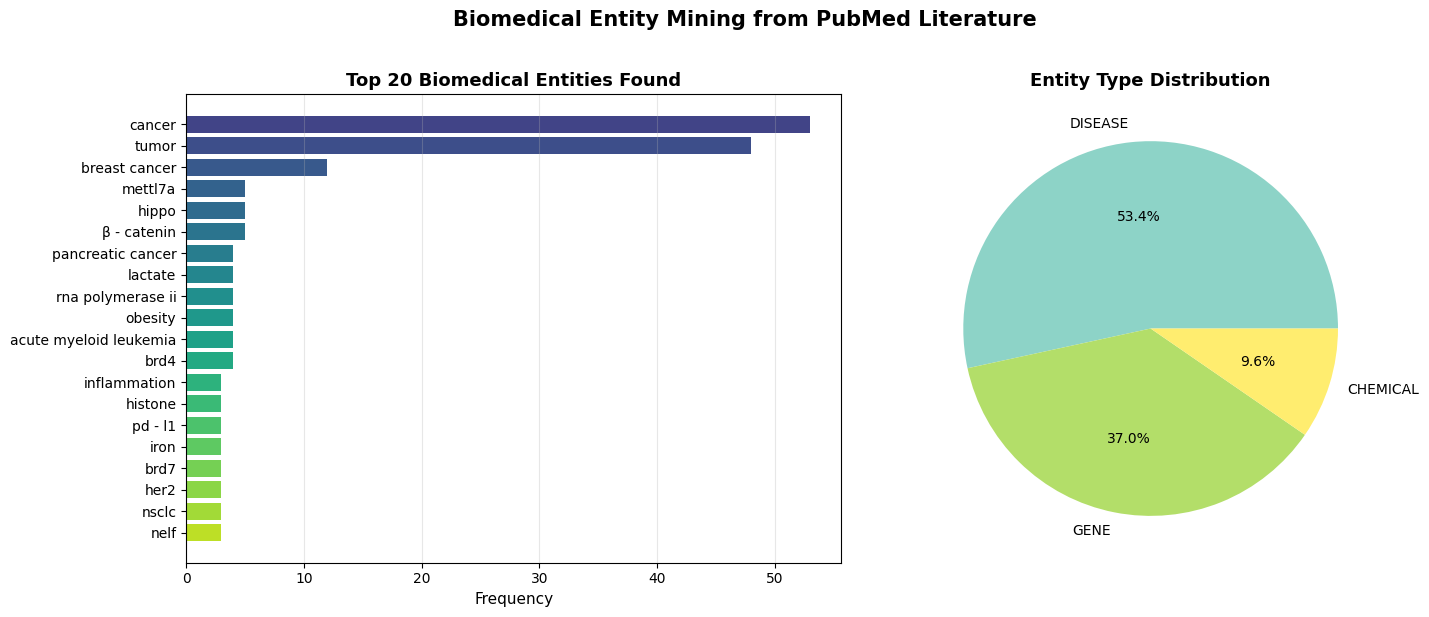

In [7]:
print("\n--- CLEANING ENTITIES ---")

# Words to exclude (author info, journal metadata, fragments)
exclude_words = {
    'author', 'information', 'department', 'university', 'institute',
    'hospital', 'school', 'cancer center', 'laboratory', 'key laboratory',
    'doi', 'epub', 'jan', 'feb', 'mar', 'apr', 'may', 'jun',
    'jul', 'aug', 'sep', 'oct', 'nov', 'dec',
    'china', 'usa', 'india', 'national', 'medicine', 'science', 'biology',
    'research', 'center', 'technology', 'life science',
    'chen', 'wang', 'zhang', 'liu', 'li', 'zhao', 'huang', 'kim', 'lee',
    'xu', 'yang', 'yan', 'sun', 'wu', 'ma', 'zhou', 'zhu', 'lin',
    'and', 'pro', 'mor', 'car', 'cin', 'state cancer', 'breast cancer state',
    'state', 'the', 'with', 'for', 'from', 'this'
}

# Clean entity names
df_entities['entity_clean'] = df_entities['entity'].str.replace(r'^##', '', regex=True).str.strip().str.lower()

# Filter out noise
df_entities = df_entities[
    (~df_entities['entity_clean'].isin(exclude_words)) &
    (df_entities['entity_clean'].str.len() >= 4) &
    (df_entities['entity_clean'].str.len() <= 35) &
    (~df_entities['entity_clean'].str.match(r'^[a-z]$')) &
    (~df_entities['entity_clean'].str.match(r'^\d+$')) &
    (~df_entities['entity_clean'].str.contains(r'\d{4}')) &
    (~df_entities['entity_clean'].str.contains(r'\.')) &
    (~df_entities['entity_clean'].str.contains(r';|:'))
]
print(f"After cleaning: {len(df_entities)} clean entities")
print(f"Unique entities: {df_entities['entity_clean'].nunique()}")

# --- NORMALIZATION (must run BEFORE csv save and before plotting) ---
canonical = {
    'tumour': 'tumor', 'tumours': 'tumor', 'tumors': 'tumor',
    'brea': 'breast cancer', 'st cancer': 'breast cancer',
    'brosis': 'fibrosis', 'leukaemia': 'leukemia',
    'acute myeloid leukaemia': 'acute myeloid leukemia',
    'urodegeneration': 'neurodegeneration',   # repair chopped 'ne'
}

def normalize(e):
    e = canonical.get(e, e)
    if e.startswith('-'):                 # leading-dash fragment ("- driven")
        return None
    if re.search(r'\s\w$', e):            # GENERIC: dangling single letter ("immune d")
        return None
    if re.fullmatch(r'[-\s]+\w?|.{1,3}', e):  # tiny/junk fragments
        return None
    return e

df_entities['entity_clean'] = df_entities['entity_clean'].map(normalize)
df_entities = df_entities[df_entities['entity_clean'].notna()]
print(f"After normalization: {df_entities['entity_clean'].nunique()} unique entities")

# Save cleaned + normalized entities
df_entities.to_csv('extracted_entities.csv', index=False)
print("\u2713 Saved extracted_entities.csv")

print("\n--- VISUALIZING TOP ENTITIES ---")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top entities by frequency (now computed AFTER normalization)
top_entities = df_entities['entity_clean'].value_counts().head(20)
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(top_entities)))

axes[0].barh(top_entities.index[::-1], top_entities.values[::-1], color=colors[::-1])
axes[0].set_xlabel('Frequency', fontsize=11)
axes[0].set_title('Top 20 Biomedical Entities Found', fontsize=13, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Entity type pie chart
type_counts = df_entities['type'].value_counts()
axes[1].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
           colors=plt.cm.Set3(np.linspace(0, 1, len(type_counts))))
axes[1].set_title('Entity Type Distribution', fontsize=13, fontweight='bold')

plt.suptitle('Biomedical Entity Mining from PubMed Literature',
            fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('top_entities.png', dpi=200, bbox_inches='tight')
plt.show()

# STEP 8: Build Co-occurrence Knowledge Graph


--- BUILDING KNOWLEDGE GRAPH ---
✓ Strong co-occurrence pairs: 16
  Nodes (entities): 13
  Edges (relationships): 14


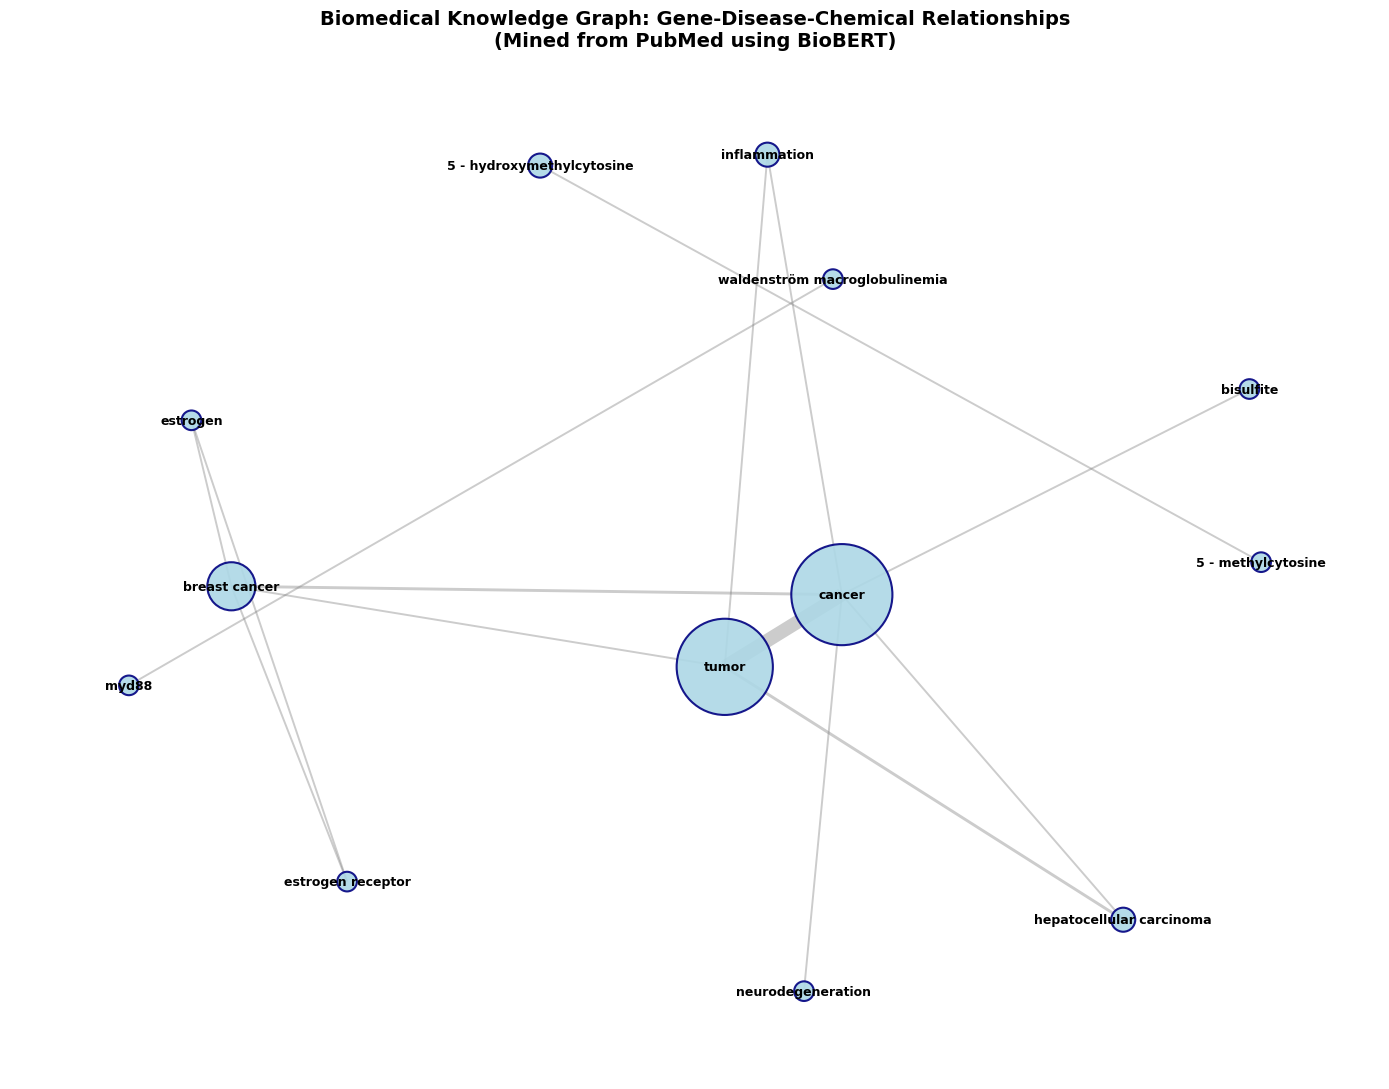

✓ Knowledge graph saved


In [8]:
print("\n--- BUILDING KNOWLEDGE GRAPH ---")

# Count co-occurrences
cooccurrence = defaultdict(int)
for abs_id in df_entities['abstract_id'].unique():
    entities_in_abs = df_entities[df_entities['abstract_id'] == abs_id]['entity_clean'].unique()
    for i, e1 in enumerate(entities_in_abs):
        for e2 in entities_in_abs[i+1:]:
            if len(e1) > 2 and len(e2) > 2:
                key = tuple(sorted([e1, e2]))
                cooccurrence[key] += 1

# Keep only strong co-occurrences (appear together in 2+ papers)
strong_pairs = {k: v for k, v in cooccurrence.items() if v >= 2}
print(f"✓ Strong co-occurrence pairs: {len(strong_pairs)}")

# Build network graph
G = nx.Graph()
for (e1, e2), weight in strong_pairs.items():
    G.add_edge(e1, e2, weight=weight)

# Keep only top entities to keep graph readable
top_entities_for_graph = df_entities['entity_clean'].value_counts().head(50).index.tolist()
G_filtered = G.subgraph([n for n in G.nodes() if n in top_entities_for_graph])

# Keep only top entities to keep graph readable
top_entities_for_graph = df_entities['entity_clean'].value_counts().head(50).index.tolist()
G_filtered = G.subgraph([n for n in G.nodes() if n in top_entities_for_graph])

# NEW: drop isolated nodes (no edges) — e.g. h3k27 with centrality 0.000
G_filtered = G_filtered.subgraph([n for n in G_filtered.nodes() if G_filtered.degree(n) > 0])

print(f"  Nodes (entities): {G_filtered.number_of_nodes()}")
print(f"  Edges (relationships): {G_filtered.number_of_edges()}")

# Visualize
plt.figure(figsize=(14, 11))
pos = nx.spring_layout(G_filtered, k=2, iterations=50, seed=42)

# Node sizes by frequency
node_sizes = [df_entities['entity_clean'].value_counts().get(n, 1) * 100
              for n in G_filtered.nodes()]

# Edge widths by co-occurrence count
edge_widths = [G_filtered[u][v]['weight'] * 0.7 for u, v in G_filtered.edges()]

nx.draw_networkx_nodes(G_filtered, pos, node_size=node_sizes,
                       node_color='lightblue', alpha=0.9,
                       edgecolors='navy', linewidths=1.5)
nx.draw_networkx_edges(G_filtered, pos, width=edge_widths,
                       alpha=0.4, edge_color='grey')
nx.draw_networkx_labels(G_filtered, pos, font_size=9, font_weight='bold')

plt.title('Biomedical Knowledge Graph: Gene-Disease-Chemical Relationships\n'
          '(Mined from PubMed using BioBERT)',
         fontsize=14, fontweight='bold', pad=15)
plt.axis('off')
plt.tight_layout()
plt.savefig('knowledge_graph.png', dpi=200, bbox_inches='tight')
plt.show()
print("✓ Knowledge graph saved")

# STEP 9: Word Cloud of Biomedical Terms


--- WORD CLOUD ---


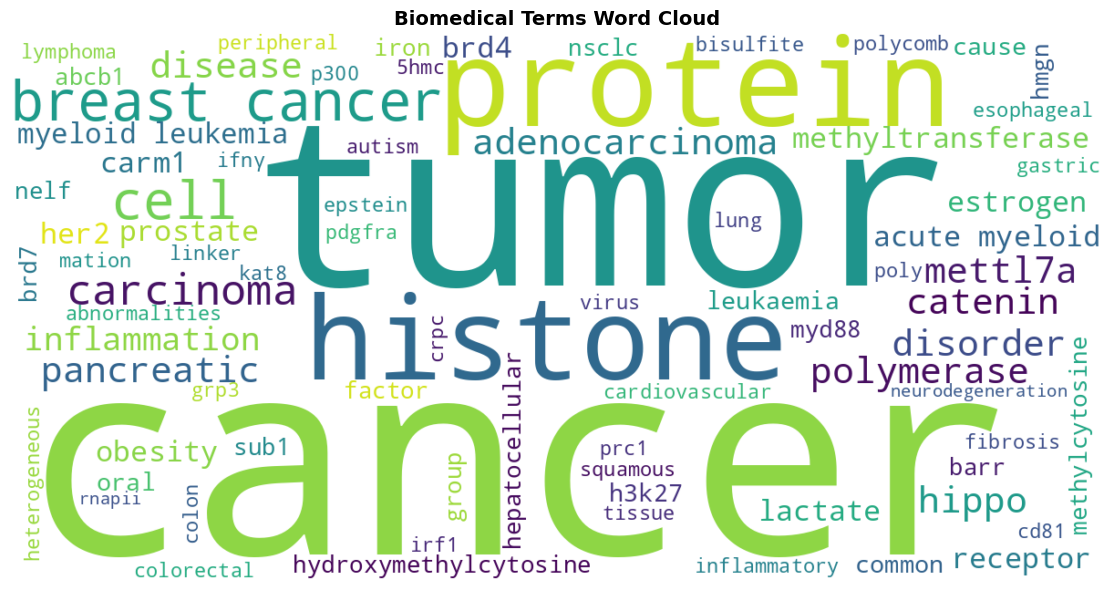

✓ Word cloud saved


In [9]:
print("\n--- WORD CLOUD ---")

from wordcloud import WordCloud, STOPWORDS

# Add custom biomedical stopwords
custom_stopwords = set(STOPWORDS).union(exclude_words)

# Combine all entities weighted by frequency
entity_freq_text = ' '.join(df_entities['entity_clean'].tolist())

wc = WordCloud(width=1200, height=600,
               background_color='white',
               colormap='viridis',
               max_words=80,
               stopwords=custom_stopwords,
               min_word_length=4,
               relative_scaling=0.5).generate(entity_freq_text)

# Display and save the word cloud (was missing before)
plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Biomedical Terms Word Cloud', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('biomedical_wordcloud.png', dpi=200, bbox_inches='tight')
plt.show()
print("\u2713 Word cloud saved")


# STEP 10: Topic-Based Analysis


--- TOPIC ANALYSIS ---


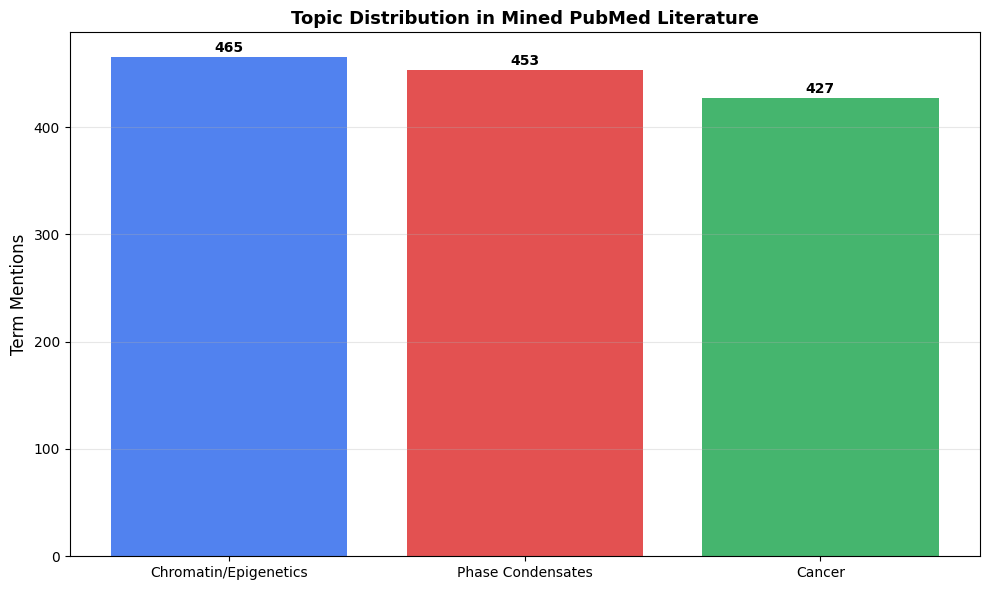

In [10]:
print("\n--- TOPIC ANALYSIS ---")

# Define topic-related keywords
chromatin_terms = ['chromatin', 'histone', 'nucleosome', 'methylation', 'acetylation',
                   'compartment', 'topologically', 'enhancer']
condensate_terms = ['condensate', 'phase', 'separation', 'liquid', 'droplet', 'membraneless']
cancer_terms = ['cancer', 'tumor', 'oncogene', 'leukemia', 'lymphoma', 'metastasis', 'apoptosis']

# Count topic-related mentions
def count_topic(abstracts, terms):
    counts = 0
    for abs_text in abstracts:
        for term in terms:
            counts += len(re.findall(term, abs_text.lower()))
    return counts

topic_counts = {
    'Chromatin/Epigenetics': count_topic(all_abstracts, chromatin_terms),
    'Phase Condensates': count_topic(all_abstracts, condensate_terms),
    'Cancer': count_topic(all_abstracts, cancer_terms)
}

plt.figure(figsize=(10, 6))
colors = ['#2563eb', '#dc2626', '#16a34a']
bars = plt.bar(topic_counts.keys(), topic_counts.values(), color=colors, alpha=0.8)
plt.ylabel('Term Mentions', fontsize=12)
plt.title('Topic Distribution in Mined PubMed Literature', fontsize=13, fontweight='bold')

# Add value labels
for bar, val in zip(bars, topic_counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('topic_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

# STEP 11: Most Connected Hubs (Important Genes/Diseases)


--- IDENTIFYING KEY HUBS ---

Top 15 most connected entities (potential drug targets):
  cancer                         centrality: 0.500
  tumor                          centrality: 0.333
  breast cancer                  centrality: 0.333
  inflammation                   centrality: 0.167
  estrogen receptor              centrality: 0.167
  estrogen                       centrality: 0.167
  hepatocellular carcinoma       centrality: 0.167
  bisulfite                      centrality: 0.083
  5 - hydroxymethylcytosine      centrality: 0.083
  5 - methylcytosine             centrality: 0.083
  neurodegeneration              centrality: 0.083
  myd88                          centrality: 0.083
  waldenström macroglobulinemia  centrality: 0.083


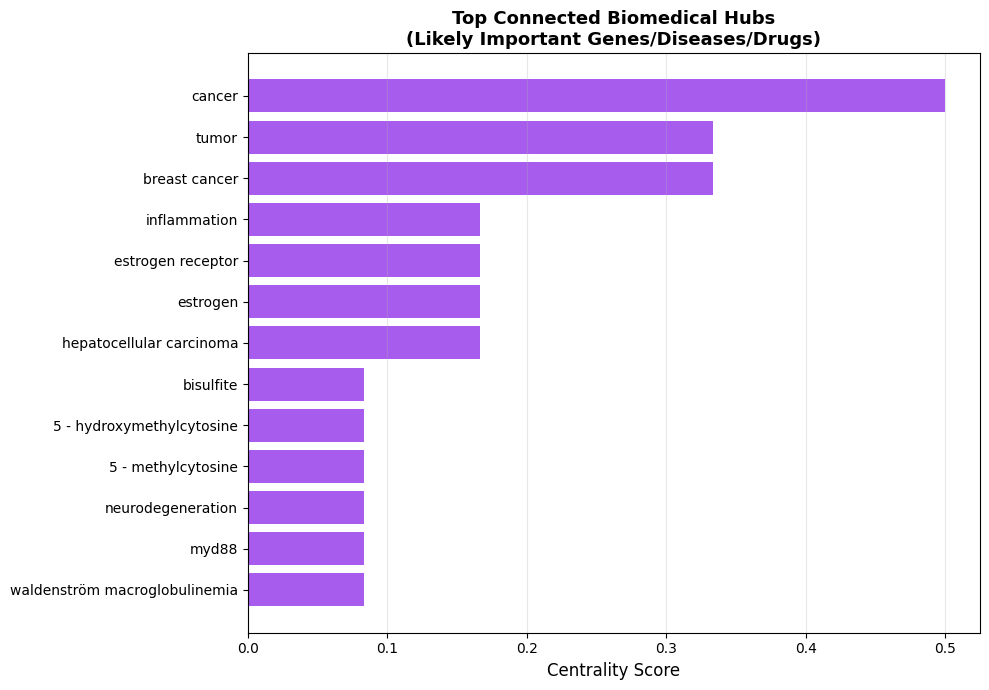

In [11]:

print("\n--- IDENTIFYING KEY HUBS ---")

# Calculate centrality - which entities are most connected?
if G_filtered.number_of_nodes() > 0:
    centrality = nx.degree_centrality(G_filtered)
    top_hubs = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:15]

    print("\nTop 15 most connected entities (potential drug targets):")
    for entity, score in top_hubs:
        print(f"  {entity:30s} centrality: {score:.3f}")

    # Visualize hubs
    plt.figure(figsize=(10, 7))
    hub_names = [h[0] for h in top_hubs]
    hub_scores = [h[1] for h in top_hubs]

    plt.barh(hub_names[::-1], hub_scores[::-1], color='#9333ea', alpha=0.8)
    plt.xlabel('Centrality Score', fontsize=12)
    plt.title('Top Connected Biomedical Hubs\n(Likely Important Genes/Diseases/Drugs)',
             fontsize=13, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('top_hubs.png', dpi=200, bbox_inches='tight')
    plt.show()

# STEP 12: Project Summary

In [12]:
print("\n" + "=" * 60)
print("BIOBERT LITERATURE MINING — PROJECT SUMMARY")
print("=" * 60)
print(f"Papers mined from PubMed:    {len(all_abstracts)}")
print(f"Total entities extracted:    {len(df_entities)}")
print(f"Unique entities:             {df_entities['entity_clean'].nunique()}")
print(f"Knowledge graph nodes:       {G_filtered.number_of_nodes()}")
print(f"Knowledge graph edges:       {G_filtered.number_of_edges()}")
print(f"")
print(f"TOPICS COVERED:")
for topic, count in topic_counts.items():
    print(f"  {topic:25s} {count} mentions")
print(f"")
print(f"FILES GENERATED:")
print(f"  - pubmed_abstracts.csv     (raw text data)")
print(f"  - extracted_entities.csv   (all entities)")
print(f"  - top_entities.png         (frequency plot)")
print(f"  - knowledge_graph.png      (entity network)")
print(f"  - biomedical_wordcloud.png (word cloud)")
print(f"  - topic_distribution.png   (topic analysis)")
print(f"  - top_hubs.png             (key hubs)")
print(f"")
print(f"BIOLOGICAL INSIGHT:")
print(f"  This project mines biomedical literature using LLMs to find:")
print(f"  • Key genes in chromatin/cancer pathways")
print(f"  • Drug targets in epigenetics")
print(f"  • Gene-disease relationships from text")
print(f"")
print(f"INDUSTRY RELEVANCE:")
print(f"  Same approach used by BenevolentAI, Recursion, Innoplexus")
print(f"  for AI-driven drug discovery from biomedical literature.")
print("=" * 60)
print(f"\nAuthor: Pradip Palekar (MT25215)")
print(f"IIIT Delhi, M.Tech Computational Biology")



BIOBERT LITERATURE MINING — PROJECT SUMMARY
Papers mined from PubMed:    135
Total entities extracted:    500
Unique entities:             298
Knowledge graph nodes:       13
Knowledge graph edges:       14

TOPICS COVERED:
  Chromatin/Epigenetics     465 mentions
  Phase Condensates         453 mentions
  Cancer                    427 mentions

FILES GENERATED:
  - pubmed_abstracts.csv     (raw text data)
  - extracted_entities.csv   (all entities)
  - top_entities.png         (frequency plot)
  - knowledge_graph.png      (entity network)
  - biomedical_wordcloud.png (word cloud)
  - topic_distribution.png   (topic analysis)
  - top_hubs.png             (key hubs)

BIOLOGICAL INSIGHT:
  This project mines biomedical literature using LLMs to find:
  • Key genes in chromatin/cancer pathways
  • Drug targets in epigenetics
  • Gene-disease relationships from text

INDUSTRY RELEVANCE:
  Same approach used by BenevolentAI, Recursion, Innoplexus
  for AI-driven drug discovery from biomedic